# QPA Results — All Experiments

This notebook loads and plots all available fidelity decay results from `data/results/`.

**Available datasets:**
- `end_to_end_unrolled_t1` — Unrolled (static) circuits, T=1, IBM Marrakesh
- `end_to_end_unrolled_t3` — Unrolled (static) circuits, T=3, IBM Marrakesh
- `end_to_end_dynamic_t1` — Dynamic circuits, T=1, IBM Marrakesh

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 10,
    'lines.linewidth': 2, 'lines.markersize': 8
})

## Load All Results

In [2]:
results_root = os.path.join("data", "results")

# Discover all CSV files
csv_files = sorted(glob.glob(os.path.join(results_root, "**", "*.csv"), recursive=True))

datasets = {}
for path in csv_files:
    rel = os.path.relpath(path, results_root)
    df = pd.read_csv(path)
    datasets[rel] = df
    print(f"{rel}: {len(df)} points, fidelity range [{df['fidelity'].min():.4f}, {df['fidelity'].max():.4f}]")

print(f"\nTotal datasets: {len(datasets)}")

end_to_end_dynamic_t1/results_n3_k2_t1_dynamic_ibm_marrakesh.csv: 25 points, fidelity range [0.2083, 0.9193]
end_to_end_dynamic_t1/results_n5_k2_t1_dynamic_ibm_marrakesh.csv: 25 points, fidelity range [0.2779, 0.9384]
end_to_end_unrolled_t1/results_n3_k2_t3_ibm_marrakesh.csv: 25 points, fidelity range [0.2694, 1.0337]
end_to_end_unrolled_t1/results_n5_k2_t3_ibm_marrakesh.csv: 25 points, fidelity range [0.2642, 1.0462]
end_to_end_unrolled_t3/results_n3_k2_t3_ibm_marrakesh.csv: 25 points, fidelity range [0.2657, 0.9364]
end_to_end_unrolled_t3/results_n5_k2_t3_ibm_marrakesh.csv: 25 points, fidelity range [0.2790, 0.8452]

Total datasets: 6


## Theory Curves

In [3]:
def theory_curve(lam, n, k=2):
    """Analytical fidelity prediction for QPA (K=2, d=4)."""
    if k == 2:
        if n == 3:
            return (1/8) * (8 - 2*lam - 7*lam**2 + 3*lam**3)
        elif n == 5:
            return (1/640) * (640 - 96*lam - 224*lam**2 - 700*lam**3 + 693*lam**4 - 153*lam**5)
    return None

lam_fine = np.linspace(0, 1, 200)
theory_n3 = theory_curve(lam_fine, 3)
theory_n5 = theory_curve(lam_fine, 5)

---
## Unrolled T=3 — IBM Marrakesh

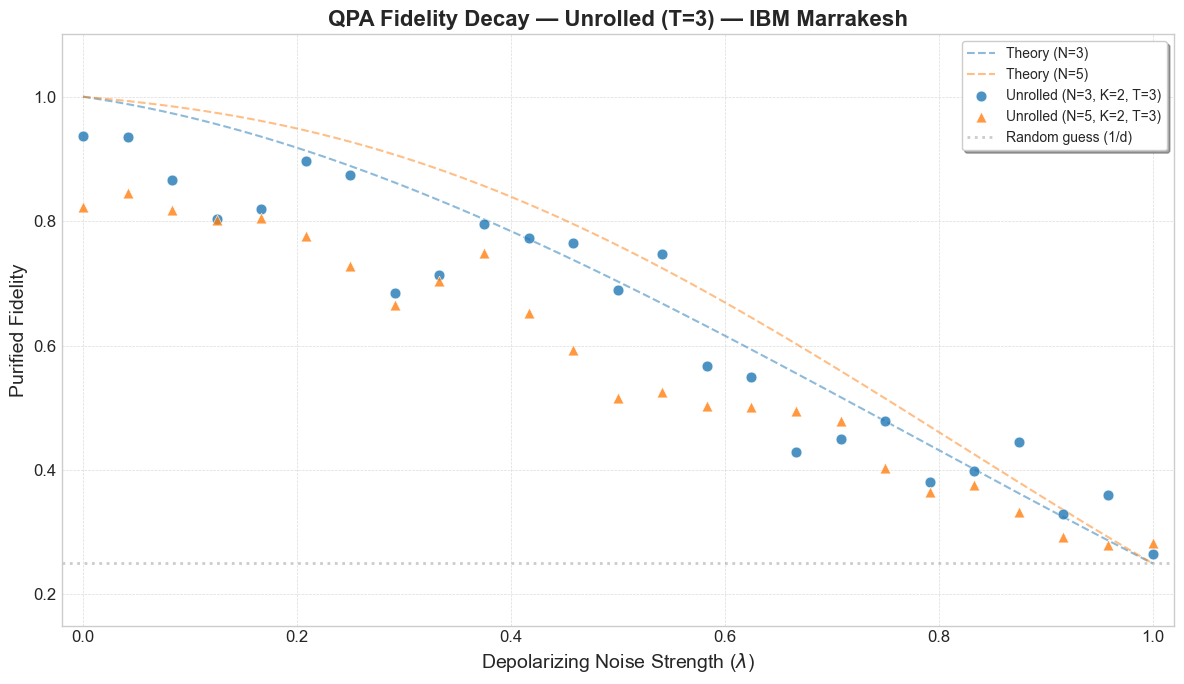

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(lam_fine, theory_n3, '--', color='#1f77b4', linewidth=1.5, alpha=0.5, label='Theory (N=3)')
ax.plot(lam_fine, theory_n5, '--', color='#ff7f0e', linewidth=1.5, alpha=0.5, label='Theory (N=5)')

key_n3 = 'end_to_end_unrolled_t3/results_n3_k2_t3_ibm_marrakesh.csv'
key_n5 = 'end_to_end_unrolled_t3/results_n5_k2_t3_ibm_marrakesh.csv'

if key_n3 in datasets:
    df = datasets[key_n3]
    ax.scatter(df['lambda'], df['fidelity'], color='#1f77b4', marker='o', s=60,
               zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
               label='Unrolled (N=3, K=2, T=3)')
if key_n5 in datasets:
    df = datasets[key_n5]
    ax.scatter(df['lambda'], df['fidelity'], color='#ff7f0e', marker='^', s=60,
               zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
               label='Unrolled (N=5, K=2, T=3)')

ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.4, label='Random guess (1/d)')
ax.set_title('QPA Fidelity Decay — Unrolled (T=3) — IBM Marrakesh', fontweight='bold')
ax.set_xlabel(r'Depolarizing Noise Strength ($\lambda$)')
ax.set_ylabel('Purified Fidelity')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.15, 1.10)
ax.legend(loc='best', frameon=True, shadow=True)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

---
## Unrolled T=1 — IBM Marrakesh

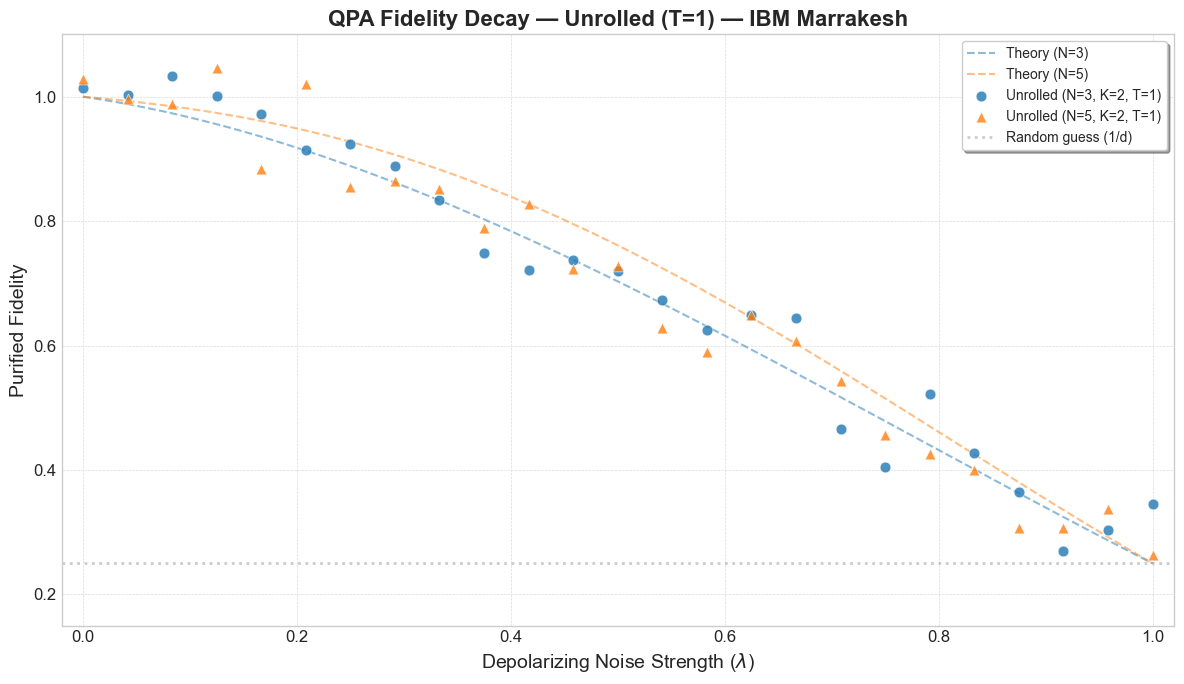

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(lam_fine, theory_n3, '--', color='#1f77b4', linewidth=1.5, alpha=0.5, label='Theory (N=3)')
ax.plot(lam_fine, theory_n5, '--', color='#ff7f0e', linewidth=1.5, alpha=0.5, label='Theory (N=5)')

key_n3 = 'end_to_end_unrolled_t1/results_n3_k2_t3_ibm_marrakesh.csv'
key_n5 = 'end_to_end_unrolled_t1/results_n5_k2_t3_ibm_marrakesh.csv'

if key_n3 in datasets:
    df = datasets[key_n3]
    ax.scatter(df['lambda'], df['fidelity'], color='#1f77b4', marker='o', s=60,
               zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
               label='Unrolled (N=3, K=2, T=1)')
if key_n5 in datasets:
    df = datasets[key_n5]
    ax.scatter(df['lambda'], df['fidelity'], color='#ff7f0e', marker='^', s=60,
               zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
               label='Unrolled (N=5, K=2, T=1)')

ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.4, label='Random guess (1/d)')
ax.set_title('QPA Fidelity Decay — Unrolled (T=1) — IBM Marrakesh', fontweight='bold')
ax.set_xlabel(r'Depolarizing Noise Strength ($\lambda$)')
ax.set_ylabel('Purified Fidelity')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.15, 1.10)
ax.legend(loc='best', frameon=True, shadow=True)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

---
## Dynamic T=1 — IBM Marrakesh

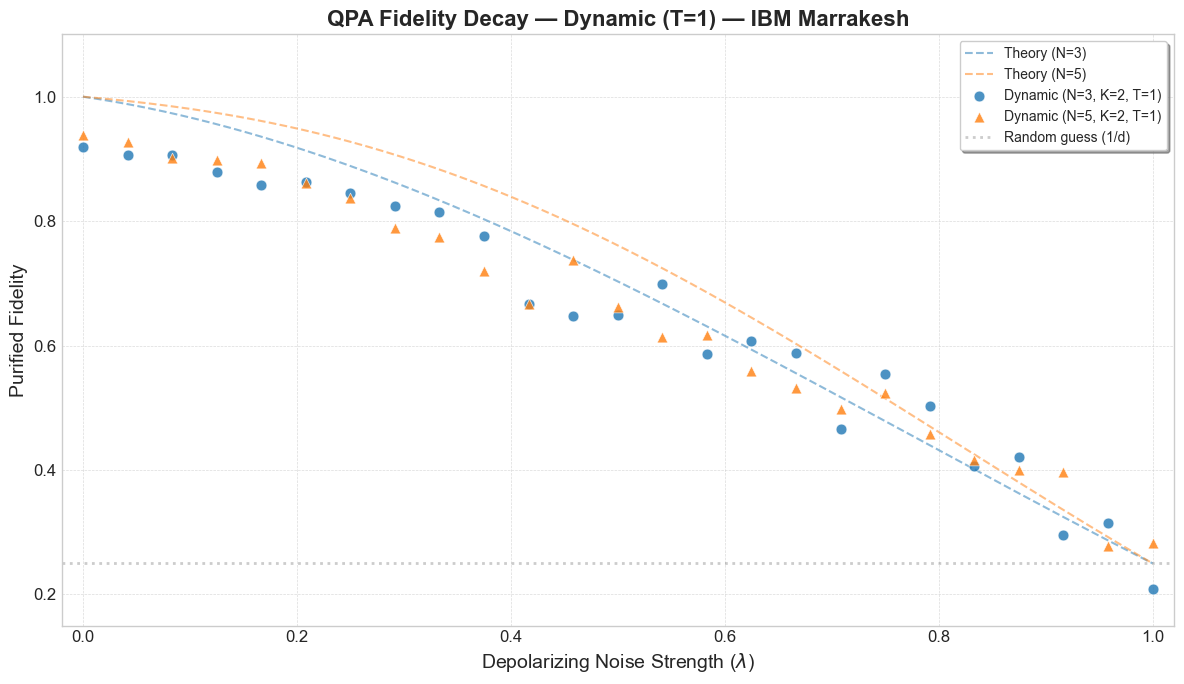

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(lam_fine, theory_n3, '--', color='#1f77b4', linewidth=1.5, alpha=0.5, label='Theory (N=3)')
ax.plot(lam_fine, theory_n5, '--', color='#ff7f0e', linewidth=1.5, alpha=0.5, label='Theory (N=5)')

key_n3 = 'end_to_end_dynamic_t1/results_n3_k2_t1_dynamic_ibm_marrakesh.csv'
key_n5 = 'end_to_end_dynamic_t1/results_n5_k2_t1_dynamic_ibm_marrakesh.csv'

if key_n3 in datasets:
    df = datasets[key_n3]
    ax.scatter(df['lambda'], df['fidelity'], color='#1f77b4', marker='o', s=60,
               zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
               label='Dynamic (N=3, K=2, T=1)')
if key_n5 in datasets:
    df = datasets[key_n5]
    ax.scatter(df['lambda'], df['fidelity'], color='#ff7f0e', marker='^', s=60,
               zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
               label='Dynamic (N=5, K=2, T=1)')

ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.4, label='Random guess (1/d)')
ax.set_title('QPA Fidelity Decay — Dynamic (T=1) — IBM Marrakesh', fontweight='bold')
ax.set_xlabel(r'Depolarizing Noise Strength ($\lambda$)')
ax.set_ylabel('Purified Fidelity')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.15, 1.10)
ax.legend(loc='best', frameon=True, shadow=True)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

---
## Combined: Dynamic vs Unrolled (T=1) — IBM Marrakesh

Blue/cyan tones for **unrolled**, red/orange tones for **dynamic**.

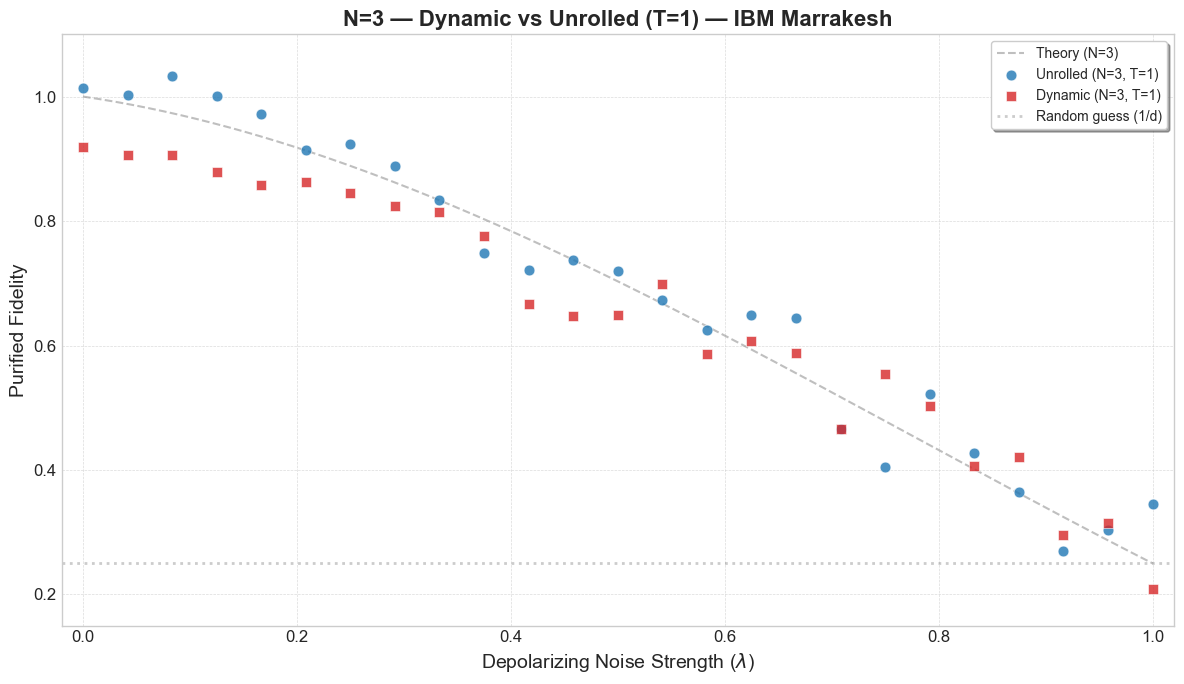

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(lam_fine, theory_n3, '--', color='gray', linewidth=1.5, alpha=0.5, label='Theory (N=3)')

# Unrolled — blue
key = 'end_to_end_unrolled_t1/results_n3_k2_t3_ibm_marrakesh.csv'
if key in datasets:
    df = datasets[key]
    ax.scatter(df['lambda'], df['fidelity'], color='#1f77b4', marker='o', s=60,
               zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
               label='Unrolled (N=3, T=1)')

# Dynamic — red
key = 'end_to_end_dynamic_t1/results_n3_k2_t1_dynamic_ibm_marrakesh.csv'
if key in datasets:
    df = datasets[key]
    ax.scatter(df['lambda'], df['fidelity'], color='#d62728', marker='s', s=60,
               zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
               label='Dynamic (N=3, T=1)')

ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.4, label='Random guess (1/d)')
ax.set_title('N=3 — Dynamic vs Unrolled (T=1) — IBM Marrakesh', fontweight='bold')
ax.set_xlabel(r'Depolarizing Noise Strength ($\lambda$)')
ax.set_ylabel('Purified Fidelity')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.15, 1.10)
ax.legend(loc='best', frameon=True, shadow=True)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

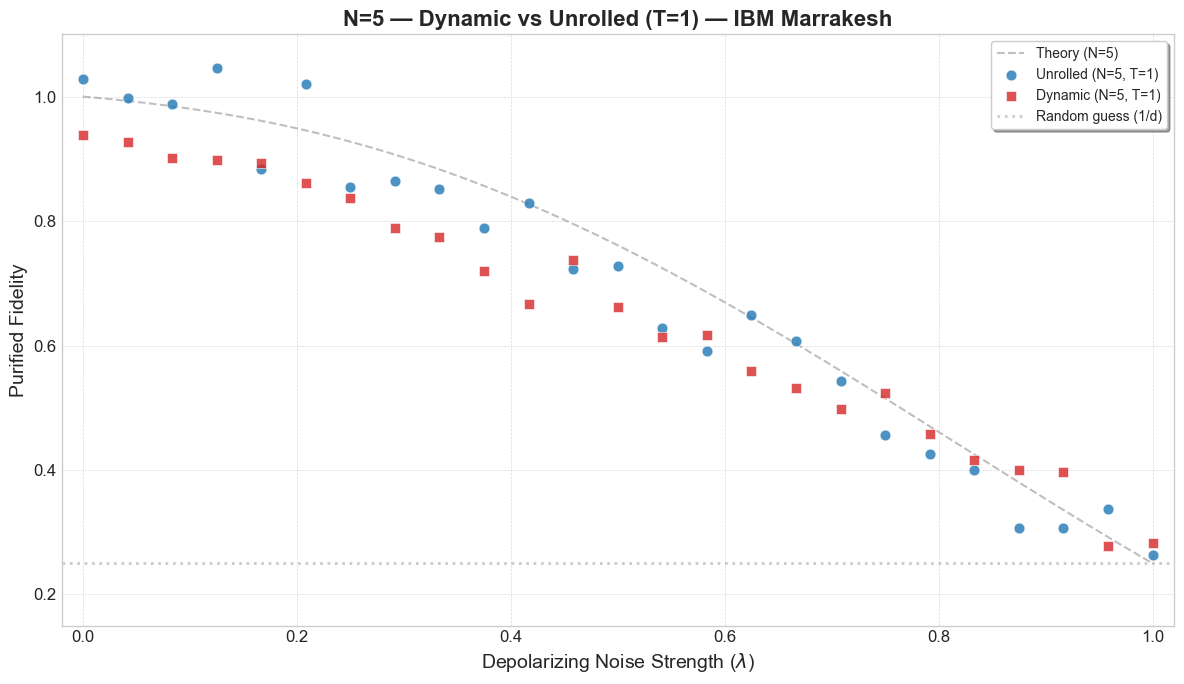

In [8]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(lam_fine, theory_n5, '--', color='gray', linewidth=1.5, alpha=0.5, label='Theory (N=5)')

# Unrolled — blue
key = 'end_to_end_unrolled_t1/results_n5_k2_t3_ibm_marrakesh.csv'
if key in datasets:
    df = datasets[key]
    ax.scatter(df['lambda'], df['fidelity'], color='#1f77b4', marker='o', s=60,
               zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
               label='Unrolled (N=5, T=1)')

# Dynamic — red
key = 'end_to_end_dynamic_t1/results_n5_k2_t1_dynamic_ibm_marrakesh.csv'
if key in datasets:
    df = datasets[key]
    ax.scatter(df['lambda'], df['fidelity'], color='#d62728', marker='s', s=60,
               zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
               label='Dynamic (N=5, T=1)')

ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.4, label='Random guess (1/d)')
ax.set_title('N=5 — Dynamic vs Unrolled (T=1) — IBM Marrakesh', fontweight='bold')
ax.set_xlabel(r'Depolarizing Noise Strength ($\lambda$)')
ax.set_ylabel('Purified Fidelity')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.15, 1.10)
ax.legend(loc='best', frameon=True, shadow=True)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

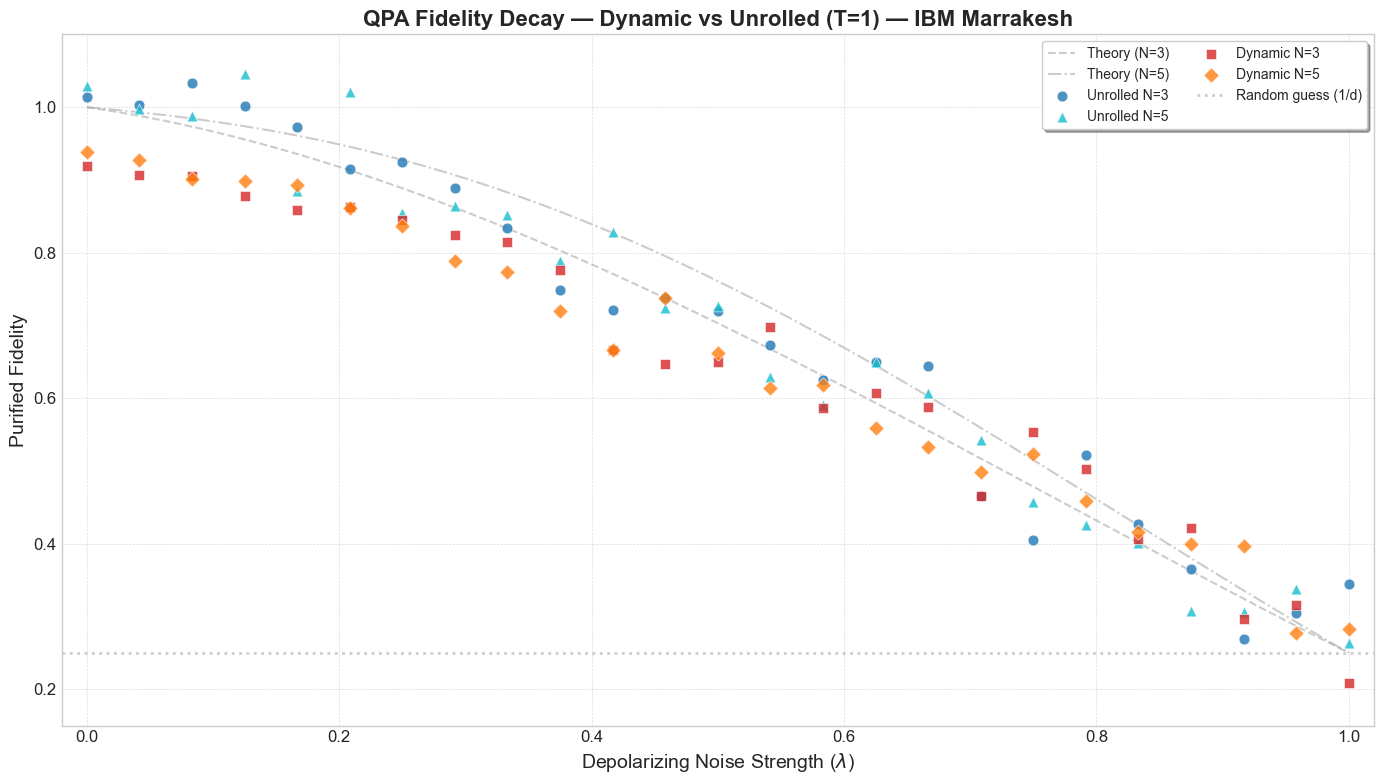

In [9]:
fig, ax = plt.subplots(figsize=(14, 8))

# Theory
ax.plot(lam_fine, theory_n3, '--', color='#aaaaaa', linewidth=1.5, alpha=0.6, label='Theory (N=3)')
ax.plot(lam_fine, theory_n5, '-.', color='#aaaaaa', linewidth=1.5, alpha=0.6, label='Theory (N=5)')

# Unrolled — blue tones
key = 'end_to_end_unrolled_t1/results_n3_k2_t3_ibm_marrakesh.csv'
if key in datasets:
    df = datasets[key]
    ax.scatter(df['lambda'], df['fidelity'], color='#1f77b4', marker='o', s=60,
               zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
               label='Unrolled N=3')

key = 'end_to_end_unrolled_t1/results_n5_k2_t3_ibm_marrakesh.csv'
if key in datasets:
    df = datasets[key]
    ax.scatter(df['lambda'], df['fidelity'], color='#17becf', marker='^', s=60,
               zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
               label='Unrolled N=5')

# Dynamic — red tones
key = 'end_to_end_dynamic_t1/results_n3_k2_t1_dynamic_ibm_marrakesh.csv'
if key in datasets:
    df = datasets[key]
    ax.scatter(df['lambda'], df['fidelity'], color='#d62728', marker='s', s=60,
               zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
               label='Dynamic N=3')

key = 'end_to_end_dynamic_t1/results_n5_k2_t1_dynamic_ibm_marrakesh.csv'
if key in datasets:
    df = datasets[key]
    ax.scatter(df['lambda'], df['fidelity'], color='#ff7f0e', marker='D', s=60,
               zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
               label='Dynamic N=5')

ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.4, label='Random guess (1/d)')
ax.set_title('QPA Fidelity Decay — Dynamic vs Unrolled (T=1) — IBM Marrakesh', fontweight='bold')
ax.set_xlabel(r'Depolarizing Noise Strength ($\lambda$)')
ax.set_ylabel('Purified Fidelity')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.15, 1.10)
ax.legend(loc='best', frameon=True, shadow=True, ncol=2)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

---
## All Experiments Overview

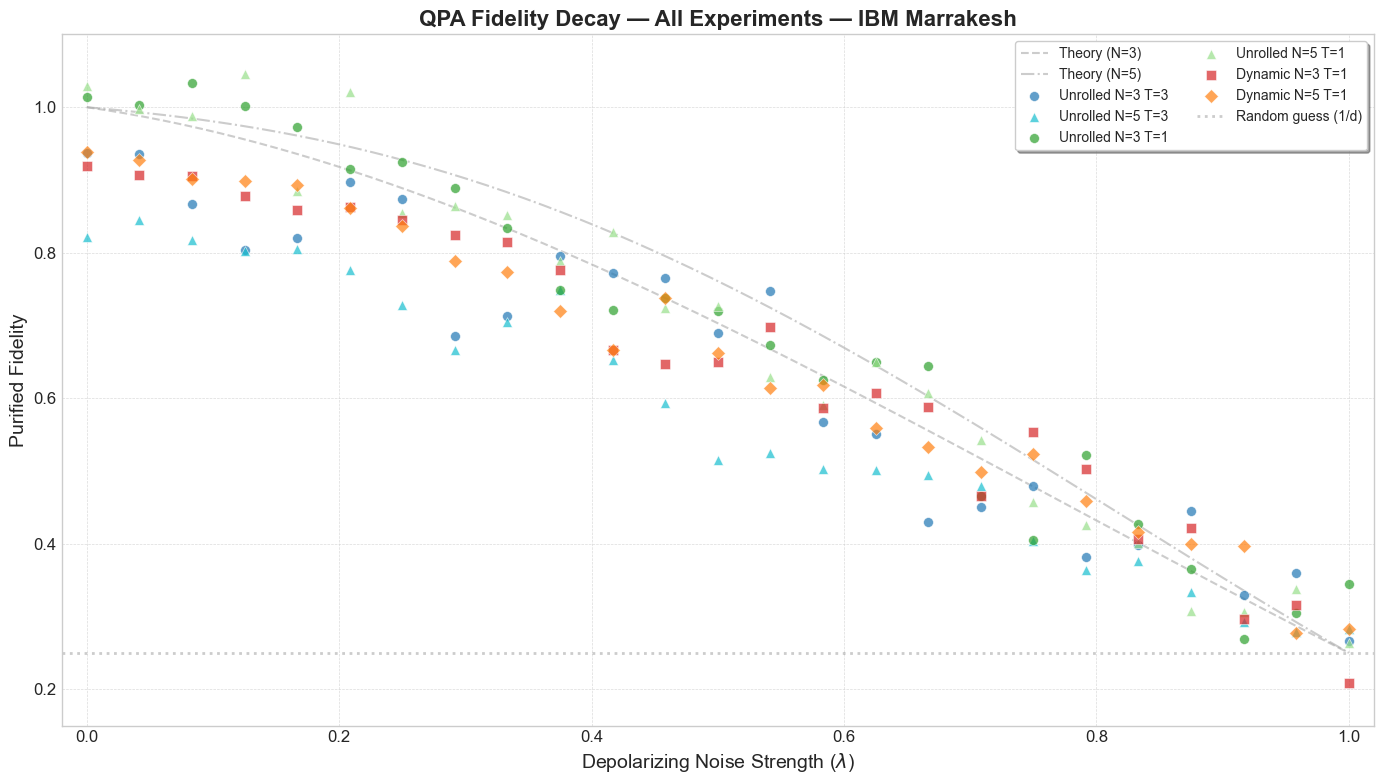

In [10]:
# Define style for each dataset
plot_configs = [
    ('end_to_end_unrolled_t3/results_n3_k2_t3_ibm_marrakesh.csv', 'Unrolled N=3 T=3', '#1f77b4', 'o'),
    ('end_to_end_unrolled_t3/results_n5_k2_t3_ibm_marrakesh.csv', 'Unrolled N=5 T=3', '#17becf', '^'),
    ('end_to_end_unrolled_t1/results_n3_k2_t3_ibm_marrakesh.csv', 'Unrolled N=3 T=1', '#2ca02c', 'o'),
    ('end_to_end_unrolled_t1/results_n5_k2_t3_ibm_marrakesh.csv', 'Unrolled N=5 T=1', '#98df8a', '^'),
    ('end_to_end_dynamic_t1/results_n3_k2_t1_dynamic_ibm_marrakesh.csv', 'Dynamic N=3 T=1', '#d62728', 's'),
    ('end_to_end_dynamic_t1/results_n5_k2_t1_dynamic_ibm_marrakesh.csv', 'Dynamic N=5 T=1', '#ff7f0e', 'D'),
]

fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(lam_fine, theory_n3, '--', color='#aaaaaa', linewidth=1.5, alpha=0.6, label='Theory (N=3)')
ax.plot(lam_fine, theory_n5, '-.', color='#aaaaaa', linewidth=1.5, alpha=0.6, label='Theory (N=5)')

for key, label, color, marker in plot_configs:
    if key in datasets:
        df = datasets[key]
        ax.scatter(df['lambda'], df['fidelity'], color=color, marker=marker, s=50,
                   zorder=5, alpha=0.7, edgecolors='white', linewidth=0.5,
                   label=label)

ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.4, label='Random guess (1/d)')
ax.set_title('QPA Fidelity Decay — All Experiments — IBM Marrakesh', fontweight='bold')
ax.set_xlabel(r'Depolarizing Noise Strength ($\lambda$)')
ax.set_ylabel('Purified Fidelity')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.15, 1.10)
ax.legend(loc='best', frameon=True, shadow=True, ncol=2)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()